# Fase 2 — EDA y limpieza

Dataset: **Almaty Air Quality History** (Kaggle, `fichka/almaty-air-quality-history`).

Objetivo de este notebook:
1. Cargar el CSV crudo y entender su esquema, nulos y rango temporal.
2. Limpiar las mediciones (drop nulos / negativos en PM2.5, parsear fechas).
3. Construir features temporales (hour, day, month, year, dayofweek).
4. Generar el target `aqi_class` con breakpoints EPA.
5. Imputar features ambientales (pm10, temperatura, humedad, um003) con la mediana.
6. Visualizar distribución de clases, evolución temporal y correlaciones.
7. Guardar `data/processed.csv` para la Fase 3 (modelado).

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

# Permitir importar src.preprocessing desde el notebook
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import (
    AQI_LABELS,
    add_aqi_class,
    clean_measurements,
    extract_temporal_features,
    impute_numeric_with_median,
    load_raw_data,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

DATA_DIR = PROJECT_ROOT / "data"
RAW_CSV = DATA_DIR / "air_quality_data.csv"
PROCESSED_CSV = DATA_DIR / "processed.csv"
print("Ruta raw:", RAW_CSV, "exists?", RAW_CSV.exists())

Ruta raw: C:\Users\esteb\Desktop\TF CLOUD\TF-Cloud\data\air_quality_data.csv exists? True


## 1. Carga e inspección inicial

In [2]:
df_raw = load_raw_data(RAW_CSV)
print("Shape:", df_raw.shape)
df_raw.head()

Shape: (544943, 12)


,datetime,location_id,pm25,pm1,pm10,relativehumidity,temperature,um003,name,lat,lon,provider_name
0,2020-04-09 16:00:00+00:00,8876,6.0,NaN,NaN,NaN,NaN,NaN,Almaty,43.252855,76.93118,AirNow
1,2020-04-09 17:00:00+00:00,8876,10.0,NaN,NaN,NaN,NaN,NaN,Almaty,43.252855,76.93118,AirNow
2,2020-04-09 18:00:00+00:00,8876,8.0,NaN,NaN,NaN,NaN,NaN,Almaty,43.252855,76.93118,AirNow
3,2020-04-09 19:00:00+00:00,8876,6.0,NaN,NaN,NaN,NaN,NaN,Almaty,43.252855,76.93118,AirNow
4,2020-04-09 20:00:00+00:00,8876,4.0,NaN,NaN,NaN,NaN,NaN,Almaty,43.252855,76.93118,AirNow


In [3]:
df_raw.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 544943 entries, 0 to 544942
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   datetime          544943 non-null  object 
 1   location_id       544943 non-null  int64  
 2   pm25              530953 non-null  float64
 3   pm1               48897 non-null   float64
 4   pm10              10203 non-null   float64
 5   relativehumidity  48897 non-null   float64
 6   temperature       48897 non-null   float64
 7   um003             48897 non-null   float64
 8   name              544943 non-null  object 
 9   lat               544943 non-null  float64
 10  lon               544943 non-null  float64
 11  provider_name     544943 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 150.9 MB


In [4]:
# Nulos por columna (absolutos y %)
nulls = pd.DataFrame({
    "nulls": df_raw.isna().sum(),
    "pct": (df_raw.isna().mean() * 100).round(2),
}).sort_values("pct", ascending=False)
nulls

,nulls,pct
pm10,534740,98.13
pm1,496046,91.03
relativehumidity,496046,91.03
temperature,496046,91.03
um003,496046,91.03
pm25,13990,2.57
datetime,0,0.00
location_id,0,0.00
name,0,0.00
lat,0,0.00


In [5]:
# Rango temporal del dataset
dt_series = pd.to_datetime(df_raw["datetime"], utc=True, errors="coerce")
print("Min datetime:", dt_series.min())
print("Max datetime:", dt_series.max())
print("Años cubiertos:", sorted(dt_series.dt.year.dropna().unique().tolist()))

Min datetime: 2020-04-09 16:00:00+00:00
Max datetime: 2026-01-07 19:00:00+00:00
Años cubiertos: [2020, 2021, 2022, 2023, 2024, 2025, 2026]


In [6]:
# Providers y estaciones únicas
print("Estaciones únicas (location_id):", df_raw["location_id"].nunique())
print("Providers:")
df_raw["provider_name"].value_counts(dropna=False)

Estaciones únicas (location_id): 146
Providers:


provider_name
Clarity        446970
AirNow          49076
AirGradient     48897
Name: count, dtype: int64

In [7]:
# Descriptivos de PM2.5 (target source)
df_raw["pm25"].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99])

count    530953.000000
mean         42.646704
std         106.211124
min           0.000000
1%            0.000000
25%           9.566667
50%          15.472222
75%          34.451250
95%         129.219910
99%         757.962500
max         999.403333
Name: pm25, dtype: float64

## 2. Limpieza + features temporales + target

In [8]:
df = clean_measurements(df_raw)
print("Filas tras limpieza:", len(df), f"({len(df)/len(df_raw)*100:.1f}% del raw)")
df = extract_temporal_features(df)
df = add_aqi_class(df)
df.head()

Filas tras limpieza: 517578 (95.0% del raw)


,datetime,location_id,pm25,pm1,pm10,relativehumidity,temperature,um003,name,lat,lon,provider_name,hour,day,month,year,dayofweek,aqi_class,aqi_label
0,2020-04-09 16:00:00,8876,6.0,NaN,NaN,NaN,NaN,NaN,Almaty,43.252855,76.93118,AirNow,16,9,4,2020,3,0,Buena
1,2020-04-09 17:00:00,8876,10.0,NaN,NaN,NaN,NaN,NaN,Almaty,43.252855,76.93118,AirNow,17,9,4,2020,3,0,Buena
2,2020-04-09 18:00:00,8876,8.0,NaN,NaN,NaN,NaN,NaN,Almaty,43.252855,76.93118,AirNow,18,9,4,2020,3,0,Buena
3,2020-04-09 19:00:00,8876,6.0,NaN,NaN,NaN,NaN,NaN,Almaty,43.252855,76.93118,AirNow,19,9,4,2020,3,0,Buena
4,2020-04-09 20:00:00,8876,4.0,NaN,NaN,NaN,NaN,NaN,Almaty,43.252855,76.93118,AirNow,20,9,4,2020,3,0,Buena


In [9]:
# Imputar columnas ambientales con la mediana
IMPUTE_COLS = ["pm10", "relativehumidity", "temperature", "um003"]
df, medians = impute_numeric_with_median(df, IMPUTE_COLS)
print("Medianas usadas para imputación:")
for k, v in medians.items():
    print(f"  {k}: {v:.3f}")
print("\nNulos restantes en columnas clave:")
df[IMPUTE_COLS + ["pm25", "aqi_class", "lat", "lon"]].isna().sum()

Medianas usadas para imputación:
  pm10: 30.161
  relativehumidity: 48.296
  temperature: 8.346
  um003: 1988.938

Nulos restantes en columnas clave:


pm10                0
relativehumidity    0
temperature         0
um003               0
pm25                0
aqi_class           0
lat                 0
lon                 0
dtype: int64

## 3. Visualizaciones

In [10]:
# Distribución de clases AQI
class_counts = (
    df["aqi_class"].value_counts().sort_index().rename("count").to_frame()
)
class_counts["label"] = class_counts.index.map(AQI_LABELS)
class_counts["pct"] = (class_counts["count"] / class_counts["count"].sum() * 100).round(2)
class_counts

,count,label,pct
aqi_class,,,
0,175205,Buena,33.85
1,212380,Moderada,41.03
2,53228,Dañina para grupos sensibles,10.28
3,54584,Dañina,10.55
4,22181,Muy dañina,4.29


C:\Users\esteb\AppData\Local\Temp\ipykernel_21036\2933223098.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\esteb\AppData\Local\Temp\ipykernel_21036\2933223098.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([AQI_LABELS[i] for i in class_counts.index], rotation=20, ha="right")


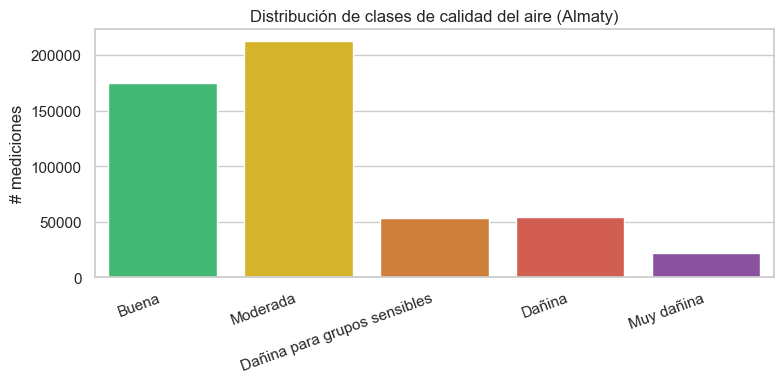

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
palette = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c", "#8e44ad"]
sns.barplot(
    x=class_counts.index,
    y=class_counts["count"],
    palette=palette[: len(class_counts)],
    ax=ax,
)
ax.set_xticklabels([AQI_LABELS[i] for i in class_counts.index], rotation=20, ha="right")
ax.set_title("Distribución de clases de calidad del aire (Almaty)")
ax.set_xlabel("")
ax.set_ylabel("# mediciones")
plt.tight_layout()
plt.show()

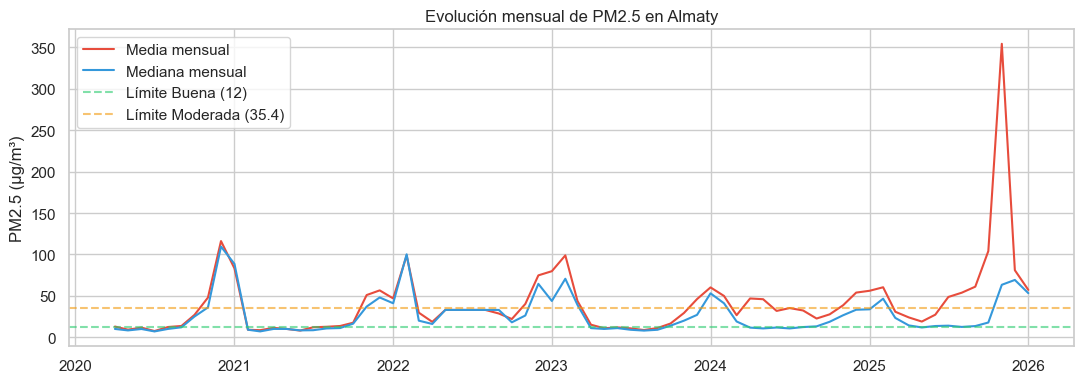

In [12]:
# Evolución temporal mensual de PM2.5
monthly = (
    df.set_index("datetime")["pm25"]
    .resample("MS")
    .agg(["mean", "median"])
    .dropna()
)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(monthly.index, monthly["mean"], label="Media mensual", color="#e74c3c")
ax.plot(monthly.index, monthly["median"], label="Mediana mensual", color="#3498db")
ax.axhline(12, ls="--", color="#2ecc71", alpha=0.6, label="Límite Buena (12)")
ax.axhline(35.4, ls="--", color="#f39c12", alpha=0.6, label="Límite Moderada (35.4)")
ax.set_title("Evolución mensual de PM2.5 en Almaty")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.legend()
plt.tight_layout()
plt.show()

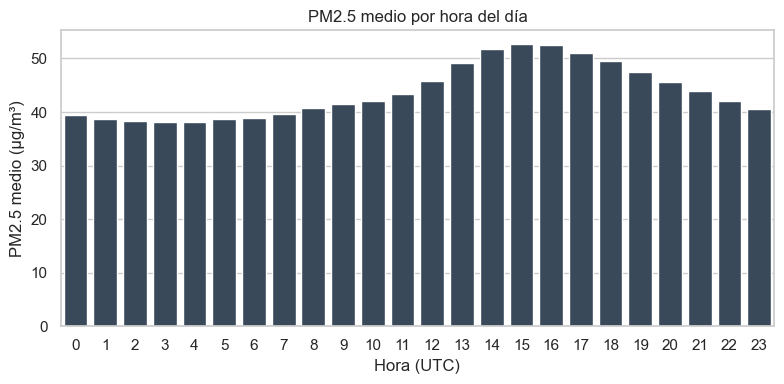

In [13]:
# PM2.5 promedio por hora del día (patrón diario)
hourly = df.groupby("hour")["pm25"].mean()
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=hourly.index, y=hourly.values, color="#34495e", ax=ax)
ax.set_title("PM2.5 medio por hora del día")
ax.set_xlabel("Hora (UTC)")
ax.set_ylabel("PM2.5 medio (µg/m³)")
plt.tight_layout()
plt.show()

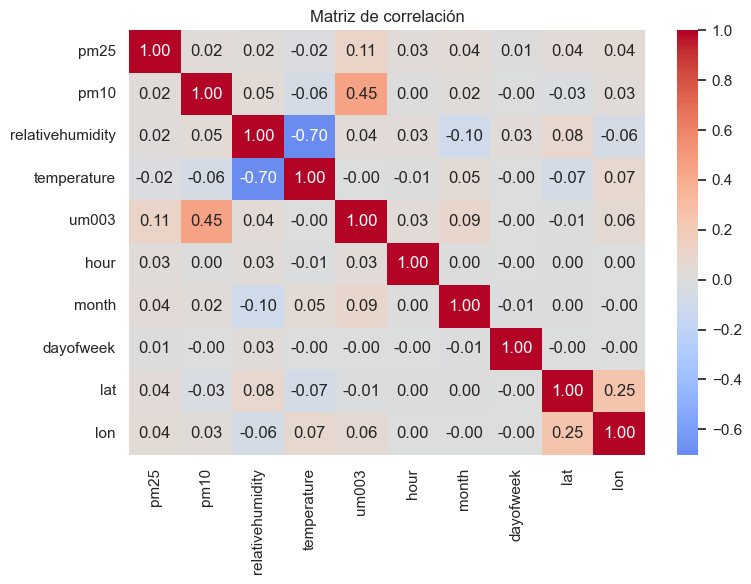

In [14]:
# Correlación entre features numéricas
num_cols = [
    "pm25", "pm10", "relativehumidity", "temperature", "um003",
    "hour", "month", "dayofweek", "lat", "lon",
]
corr = df[num_cols].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Matriz de correlación")
plt.tight_layout()
plt.show()

## 4. Guardar dataset procesado

In [15]:
# Columnas finales que persistimos
FINAL_COLS = [
    "datetime", "location_id", "name", "provider_name", "lat", "lon",
    "pm25", "pm10", "relativehumidity", "temperature", "um003",
    "hour", "day", "month", "year", "dayofweek",
    "aqi_class", "aqi_label",
]
df_final = df[FINAL_COLS].copy()
df_final.to_csv(PROCESSED_CSV, index=False)
print("Guardado:", PROCESSED_CSV)
print("Shape final:", df_final.shape)
df_final.head()

Guardado: C:\Users\esteb\Desktop\TF CLOUD\TF-Cloud\data\processed.csv
Shape final: (517578, 18)


,datetime,location_id,name,provider_name,lat,lon,pm25,pm10,relativehumidity,temperature,um003,hour,day,month,year,dayofweek,aqi_class,aqi_label
0,2020-04-09 16:00:00,8876,Almaty,AirNow,43.252855,76.93118,6.0,30.161375,48.295834,8.345833,1988.9375,16,9,4,2020,3,0,Buena
1,2020-04-09 17:00:00,8876,Almaty,AirNow,43.252855,76.93118,10.0,30.161375,48.295834,8.345833,1988.9375,17,9,4,2020,3,0,Buena
2,2020-04-09 18:00:00,8876,Almaty,AirNow,43.252855,76.93118,8.0,30.161375,48.295834,8.345833,1988.9375,18,9,4,2020,3,0,Buena
3,2020-04-09 19:00:00,8876,Almaty,AirNow,43.252855,76.93118,6.0,30.161375,48.295834,8.345833,1988.9375,19,9,4,2020,3,0,Buena
4,2020-04-09 20:00:00,8876,Almaty,AirNow,43.252855,76.93118,4.0,30.161375,48.295834,8.345833,1988.9375,20,9,4,2020,3,0,Buena


## Notas para la Fase 3

- **Target**: `aqi_class` (0-4)
- **Features candidatas**: `pm10`, `relativehumidity`, `temperature`, `um003`, `hour`, `day`, `month`, `dayofweek`, `lat`, `lon`
- **NO usar como feature**: `pm25` (data leakage, el target se deriva de ahí).
- Las medianas de imputación quedan en la variable `medians` — se guardarán junto al modelo para que la API pueda imputar inputs del usuario que vengan vacíos.